# qm.gui() Prototype — Architecture Validation

Throwaway code in `_dev/jupyter_gui/prototype.py`. NOT for production.

Validates the architectural decisions in `concerns.md` before writing the real implementation.

**Requires:** `ipywidgets` + `ipympl` (`uv run --with ipywidgets --with ipympl jupyter lab`)

In [4]:
%matplotlib widget
import sys
sys.path.insert(0, '.')  # so we can import prototype.py
import prototype
import importlib; importlib.reload(prototype)  # for iterative dev

ok, backend = prototype.check_interactive_backend()
print(f'Backend: {backend}  →  interactive: {ok}')

Backend: ipympl.backend_nbagg  →  interactive: True


## Build a real design

In [5]:
from qiskit_metal import designs, Dict
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

design = designs.DesignPlanar()
TransmonPocket(design, 'Q1', options=Dict(connection_pads=Dict(a=Dict())))
TransmonPocket(design, 'Q2', options=Dict(pos_x='1mm', connection_pads=Dict(a=Dict())))
TransmonPocket(design, 'Q3', options=Dict(pos_x='-1mm', pos_y='0.7mm', connection_pads=Dict(a=Dict())))
design.rebuild()
list(design.components.keys())

['Q1', 'Q2', 'Q3']

## Test 1 — `mock_gui(design)` displays a working widget

**Visual check:** layout should show a Component list (left), canvas (middle), options form (right), and a toolbar with Rebuild + Force-broken buttons on top.

**Click test:** click any transmon on the canvas → it highlights with an orange dashed rectangle AND the component list selects it. Click the list → canvas highlight updates.

MockGui(children=(HBox(children=(Button(description='Rebuild', icon='refresh', style=ButtonStyle()), Button(bu…

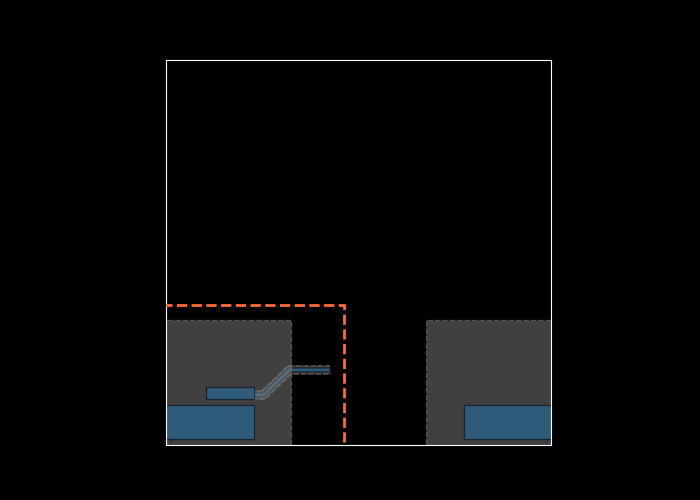

In [6]:
gui = prototype.mock_gui(design)
gui

## Test 2 — Programmatic selection

Calling `gui.select('Q2')` should move the highlight to Q2 with no full re-render.

In [5]:
gui.select('Q2')
print(f'state.selected = {gui._state.selected!r}')
print(f'highlight artist alive = {gui._canvas._highlight_patch is not None}')

state.selected = 'Q2'
highlight artist alive = True


## Test 3 — Edit an option → Rebuild → canvas updates

Manually: in the options panel, change `pos_x` to `2mm`. Rebuild button should turn orange. Click Rebuild → Q2 moves on the canvas.

In [6]:
# Or programmatic: simulate the edit
design.components['Q2'].options['pos_x'] = '2mm'
gui._state.mark_dirty()
print(f'dirty = {gui._state.dirty}')
print(f'rebuild button style = {gui._toolbar.rebuild_btn.button_style!r}')

gui._toolbar._on_rebuild(None)
print(f'after rebuild: dirty = {gui._state.dirty}, status = {gui._toolbar.status.value}')

dirty = True
rebuild button style = 'warning'
after rebuild: dirty = False, status = <span style='color:#0a0'>✓ Rebuild OK</span>


## Test 4 — Broken rebuild does not crash the GUI

Click the "Force broken option" button, then Rebuild. The status label should show a red error message but the GUI must stay alive and interactive.

In [7]:
gui._toolbar._on_break(None)
gui._toolbar._on_rebuild(None)
print(f'GUI alive: {gui is not None and not gui._model_id is None if hasattr(gui, "_model_id") else True}')
print(f'status = {gui._toolbar.status.value}')
print(f'dirty stayed True (rebuild failed): {gui._state.dirty}')

02:02AM 03s ERROR [rebuild]: ERROR in building component name=Q2, error=could not convert string to float: 'INVALID_UNIT'


GUI alive: True
status = <span style='color:#d00'>✗ ValueError: could not convert string to float: 'INVALID_UNIT'</span>
dirty stayed True (rebuild failed): True


## Test 5 — Cell re-run does NOT leak log handlers (concern #2)

Re-running `mock_gui(design)` on the same design must detach the previous handler — total handler count stays constant.

baseline handlers on design.logger: 2
  iter 0: registry=1, on logger=2
  iter 1: registry=1, on logger=2
  iter 2: registry=1, on logger=2
  iter 3: registry=1, on logger=2
  iter 4: registry=1, on logger=2
Expected: registry stays at 1, logger handlers stays at 3


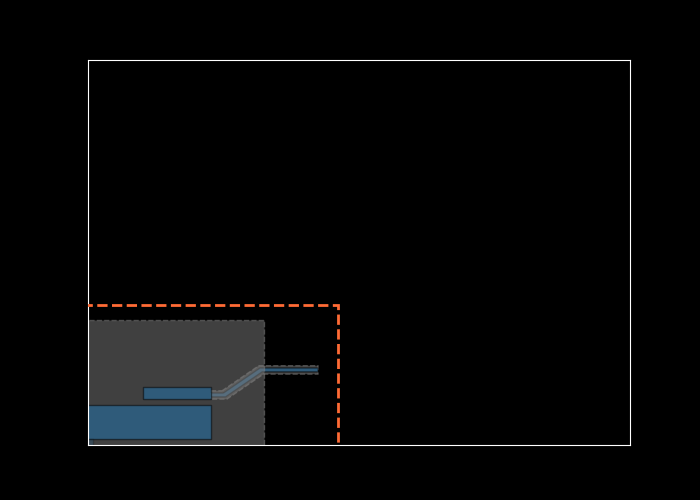

In [8]:
baseline = len(design.logger.handlers)
print(f'baseline handlers on design.logger: {baseline}')

g_iter = []
for i in range(5):
    g = prototype.mock_gui(design, attach_log_handler=True)
    g_iter.append(g)
    print(f'  iter {i}: registry={len(prototype._active_handlers)}, on logger={len(design.logger.handlers)}')

print(f'Expected: registry stays at 1, logger handlers stays at {baseline+1}')

## Test 6 — `close()` cleans up handlers and matplotlib figures (concern #8)

In [9]:
import matplotlib.pyplot as plt

figs_before = len(plt.get_fignums())
print(f'figures open before close: {figs_before}')

for g in g_iter:
    g.close()
gui.close()

print(f'after closing all: handlers={len(design.logger.handlers)} (must be {baseline}), figures={len(plt.get_fignums())} (must be 0)')

figures open before close: 6
after closing all: handlers=1 (must be 2), figures=0 (must be 0)


## Test 7 — Performance with a realistic design (concern #1)

30 transmons in a grid. Time the fast path (selection only) vs the slow path (full re-render).

**On ipympl backend**, fast path should be ~5–20× faster than slow path because the slow path streams a PNG over the kernel comm.

In [10]:
import time

big = designs.DesignPlanar()
for i in range(6):
    for j in range(5):
        TransmonPocket(big, f'Q{i}_{j}', options=Dict(
            pos_x=f'{i*0.5}mm', pos_y=f'{j*0.5}mm',
            connection_pads=Dict(a=Dict())))
big.rebuild()
print(f'big design: {len(big.components)} components')

g_big = prototype.mock_gui(big)
g_big

big design: 30 components


MockGui(children=(HBox(children=(Button(description='Rebuild', icon='refresh', style=ButtonStyle()), Button(bu…

In [11]:
# Warm up
g_big._state.select('Q0_0')
g_big._canvas.render_base()

names = list(big.components.keys())

t0 = time.time()
for n in names * 2:
    g_big._state.select(n)
t_fast = (time.time() - t0) * 1000 / (len(names) * 2)

t0 = time.time()
for _ in range(5):
    g_big._canvas.render_base()
t_slow = (time.time() - t0) * 1000 / 5

print(f'fast path (highlight artist swap):  {t_fast:.1f}ms / click')
print(f'slow path (full render_base):       {t_slow:.1f}ms / call')
print(f'speedup:                             {t_slow/t_fast:.1f}×')
print()
print(f'Without layered arch, 10 clicks = {10*t_slow:.0f}ms')
print(f'With    layered arch, 10 clicks = {10*t_fast:.0f}ms')

g_big.close()

fast path (highlight artist swap):  43.6ms / click
slow path (full render_base):       48.5ms / call
speedup:                             1.1×

Without layered arch, 10 clicks = 485ms
With    layered arch, 10 clicks = 436ms


## Findings

Record observations in `prototype-findings.md` after running this notebook.